# Group 25: Climate/Agriculture
### Milestone 44

In [57]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

# Loading the dataset
data = pd.read_csv('Iowa_Corn.csv')
climate = pd.read_csv('climate.csv')

# Corn Yield Modeling Based on Weather Factors
This notebook explores and preprocesses data to analyze corn yield trends and their relationship with weather factors. The workflow includes:
- Exploratory Data Analysis (EDA)
- Preprocessing (weather data cleaning, feature engineering, standardization, and encoding)
oding


## 1. Loading Data and EDA
We are working with two datasets: (1) a dataset that gives information on corn yield for different counties in Iowa. An important feature of this dataset is that it also gives the year the data was collected, which will be important for seeing the potential relationship between climate change and crop output, and (2) a dataset that gives climate data measured by 10 different stations throughout Iowa. The dataset gives daily weather information for each of the stations, with information on max and min temperaperature, and precipitation. For consistency in units, we will only measure yield output using yield measured in BU / ACRE, which is the most common measuring unit in the dataset.

Filtering Corn Yield Data

The dataset is filtered to retain only rows where the "Data Item" corresponds to corn yield measured in BU / ACRE, the standard unit for crop yield. The Year and Value columns are converted to numeric, ensuring data consistency. Rows with missing or invalid values are removed for reliability in subsequent analyses.

Aggregating and Visualizing Yield Trends

We calculate the average corn yield per year and visualize trends over time using scatter plots for individual data points and a line graph for yearly averages. The visualization reveals a general upward trend in corn yield, suggesting significant agricultural advancements, such as improved technology and farming practices, over the past century..


Corn dataset:
  Program  Year Period  Week Ending Geo Level State  State ANSI Ag District  \
0  SURVEY  2023   YEAR          NaN    COUNTY  IOWA          19         NaN   
1  SURVEY  2023   YEAR          NaN    COUNTY  IOWA          19         NaN   
2  SURVEY  2023   YEAR          NaN    COUNTY  IOWA          19         NaN   
3  SURVEY  2023   YEAR          NaN    COUNTY  IOWA          19         NaN   
4  SURVEY  2023   YEAR          NaN    COUNTY  IOWA          19         NaN   

   Ag District Code          County  ...  Zip Code  Region  watershed_code  \
0                99  OTHER COUNTIES  ...       NaN     NaN               0   
1                99  OTHER COUNTIES  ...       NaN     NaN               0   
2                99  OTHER COUNTIES  ...       NaN     NaN               0   
3                99  OTHER COUNTIES  ...       NaN     NaN               0   
4                99  OTHER COUNTIES  ...       NaN     NaN               0   

   Watershed  Commodity                   

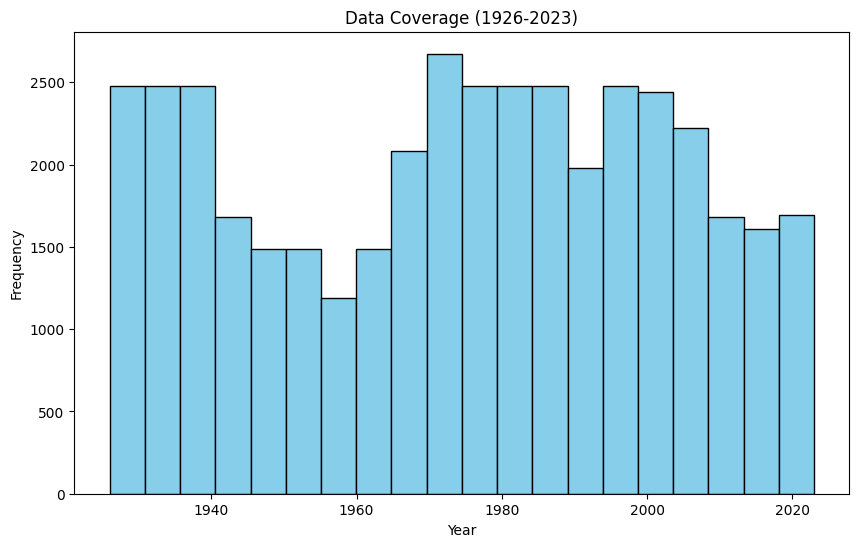

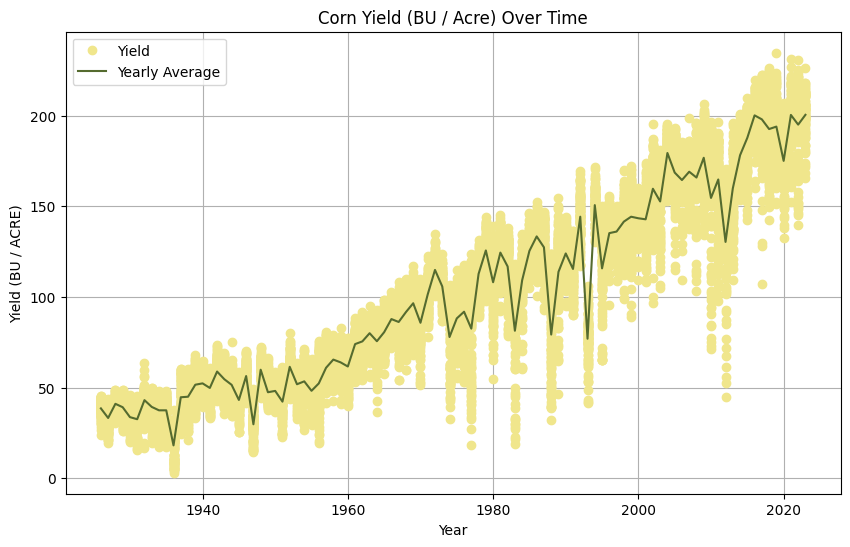

In [58]:
# Inspecting datasets
print("Corn dataset:")
print(data.head())
print("\nClimate dataset:")
print(climate.head())

# Exploring unique data items in corn data
print("Unique data items:", data['Data Item'].unique())

# Visualizing data coverage over years
plt.figure(figsize=(10, 6))
plt.hist(data['Year'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title(f'Data Coverage ({data['Year'].min()}-{data['Year'].max()})')
plt.show()

# Filtering corn yield data
# For consistency in units, we will only measure yield output using yield measured in BU / ACRE,
# which is the most common measuring unit in the dataset.
yield_ = data[data['Data Item'] == 'CORN, GRAIN - YIELD, MEASURED IN BU / ACRE'].copy()

yield_.loc[:, 'Year'] = pd.to_numeric(yield_['Year'], errors='coerce')
yield_.loc[:, 'Value'] = pd.to_numeric(yield_['Value'].str.replace(',', ''), errors='coerce')
yield_= yield_.dropna(subset=['Year', 'Value'])
yield_.head(1)

# Aggregating yearly averages and visualizing yield trends
average_yield_per_year = yield_.groupby('Year')['Value'].mean()

plt.figure(figsize=(10, 6))
plt.plot(yield_['Year'], yield_['Value'], marker='o', color='khaki', linestyle='', label='Yield')

plt.plot(average_yield_per_year.index, average_yield_per_year, color='darkolivegreen', linestyle='-', label='Yearly Average')

plt.title('Corn Yield (BU / Acre) Over Time')
plt.xlabel('Year')
plt.ylabel('Yield (BU / ACRE)')
plt.grid()
plt.legend()
plt.show()


This graph shows the total corn yield (bushels produced / acres planted) in Iowa, plotted as a function of time. It clearly shows a trend of gene increasing crop yield, likely indicative of improvements in agricultural technology over the past century that have increased the efficiency of each harvest (1). These advancements have increased the average corn yields from approximately 30 bushels per acre to over 170 bushels per acre in recent years (2). As such, we will be using ‘year’ as one of our predictors in the model – in addition to all of the climate data – as a proxy for these agrotechnological improvements. We should note that there are also a few pronounced spikes or dips in the average yield that may require further investigation and may be due to extenuating circumstances.

## 1.3 Exploring Climate Data


#### Displaying Structure and Record Counts
This section begins by displaying the first few rows of the climate dataset to understand its structure and contents. The total number of records is printed to give a sense of the dataset's size. The occurrence counts of unique weather stations are summarized and sorted to identify the most frequently recorded stations.

#### Extracting and Filtering Time Information
The `DATE` column is converted into datetime format to extract `Year`, `Month`, and `Day`. The dataset is then filtered to include only the growing season, defined as May 1 to October 15. This ensures that subsequent analyses focus on the months most relevant to crop growth.

#### Aggregating Key Climate Variables
1. **Total Precipitation**: Summed per station, year, and location (`PRCP`) to capture water availability during the growing season.  
2. **Hot Shocks**: Days with maximum temperatures above 90°F are counted, indicating extreme heat events that can stress crops.  
3. **Cold Shocks**: Days with minimum temperatures below 32°F are counted to assess frost risk.  
4. **Growing Degree Days (GDD)**: Calculated as the average temperature above a threshold of 50°F, a measure of cumulative heat beneficial for crop growth.

#### Merging Climate Metrics
The calculated metrics are merged into a single `climate_summary` table, grouped by station, name, and year. Missing values for hot and cold shocks are replaced with zeros for consistency. Finally, the station ID and name columns are renamed to `id` and `name` for clarity, and the updated dataset is previewed. This summary provides a concise dataset of key climate factors for analysis and modeling.


In [59]:
# Display climate data structure and basic statistics
print(climate.head())
print(f"Number of climate records: {len(climate)}")

name_counts = climate['STATION'].value_counts()
name_table = name_counts.reset_index()
name_table.columns = ['STATION', 'Count']
name_table = name_table.sort_values(by='Count', ascending=False)

print(name_table)

# Extract time data
climate['DATE'] = pd.to_datetime(climate['DATE'])
climate['Year'] = climate['DATE'].dt.year
climate['Month'] = climate['DATE'].dt.month
climate['Day'] = climate['DATE'].dt.day

# filter dataset for growing season
climate_filtered = climate[
    ((climate['Month'] == 5) & (climate['Day'] >= 1)) | # May 1st to May 31st
    ((climate['Month'] > 5) & (climate['Month'] < 10)) | # June to September
    ((climate['Month'] == 10) & (climate['Day'] <= 15))  # October 1st to October 15th
]

climate = climate_filtered.drop(columns=['Month', 'Day'])

total_precip = climate.groupby(['STATION', 'NAME', 'Year'])['PRCP'].sum().reset_index(name='prcp')

# Hot Shock
days_above = climate[climate['TMAX'] > 90].groupby(['STATION', 'NAME', 'Year']).size().reset_index(name='days_above')

# Cold Shock
days_below = climate[climate['TMIN'] < 32].groupby(['STATION', 'NAME', 'Year']).size().reset_index(name='days_below')

# Calculate GDD
climate['TAVG'] = (climate['TMAX'] + climate['TMIN']) / 2
climate['GDD'] = np.maximum(((climate['TMAX'] + climate['TMIN']) / 2) - 50, 0)
yearly_avg_temp = climate.groupby(['STATION', 'NAME', 'Year'])['GDD'].mean().reset_index(name='gdd')

# Merge
climate_summary = (
    total_precip
    .merge(days_above, on=['STATION', 'NAME', 'Year'], how='left')
    .merge(days_below, on=['STATION', 'NAME', 'Year'], how='left')
    .merge(yearly_avg_temp, on=['STATION', 'NAME', 'Year'], how='left')
)

climate_summary['days_above'] = climate_summary['days_above'].fillna(0)
climate_summary['days_below'] = climate_summary['days_below'].fillna(0)

climate_summary.rename(columns={'STATION': 'id', 'NAME': 'name'}, inplace=True)
climate_summary.head()


       STATION                     NAME        DATE  EVAP  PRCP  TMAX  TMIN
0  USC00131635  CLINTON NUMBER 1, IA US  1926-01-01   NaN  0.00  39.0  18.0
1  USC00131635  CLINTON NUMBER 1, IA US  1926-01-02   NaN  0.00  31.0  19.0
2  USC00131635  CLINTON NUMBER 1, IA US  1926-01-03   NaN  0.00  36.0  24.0
3  USC00131635  CLINTON NUMBER 1, IA US  1926-01-04   NaN  0.45  44.0  34.0
4  USC00131635  CLINTON NUMBER 1, IA US  1926-01-05   NaN  0.00  44.0  32.0
Number of climate records: 356598
       STATION  Count
0  USC00131635  35795
1  USC00138688  35726
2  USC00130600  35717
3  USC00134735  35716
4  USC00131442  35673
5  USC00138296  35671
6  USC00131533  35641
7  USC00131319  35589
8  USC00131233  35559
9  USC00137386  35511


,id,name,Year,prcp,days_above,days_below,gdd
0,USC00130600,"BELLE PLAINE, IA US",1926,27.54,18.0,1.0,17.647590
1,USC00130600,"BELLE PLAINE, IA US",1927,24.63,22.0,1.0,15.827381
2,USC00130600,"BELLE PLAINE, IA US",1928,25.27,14.0,5.0,16.732143
3,USC00130600,"BELLE PLAINE, IA US",1929,17.65,17.0,6.0,16.020833
4,USC00130600,"BELLE PLAINE, IA US",1930,19.25,39.0,0.0,19.261905


Above, we create a new dataframe, climate_summary, that gives information from each station grouped by year. It will give the total precipitation, the number of days over 90 degrees and number of days below 32 degrees over the entire growing season (May 1st to October 15th). We also have a new measurement, GDD. The GDD for each day is found using the formula:

    GDD = (TMAX + TMIN) / 2 - TBASE.

The TBASE term will vary by crop, but it is found to be 50 degrees for corn. Growing degree days are used to estimate the developmental stage of the crop and will be a useful predictor for crop yield in our model.

# 2. Data Preprocessing
## 2.1 Merging and Feature Engineering


The number of unique station names and the frequency of station IDs are summarized to understand the distribution of climate data across locations. A mapping dictionary is used to associate station IDs with corresponding counties, enabling integration of climate data with yield data by geographic region. The resulting `climate_summary` dataset includes a new `County` column for streamlined analysis and is previewed to confirm the successful mapping.

In [60]:
climate_summary['name'].nunique()
name_counts = climate_summary['id'].value_counts()

name_table = name_counts.reset_index()
name_table.columns = ['id', 'Count']

name_table = name_table.sort_values(by='Count', ascending=False)

print(name_table)

id_to_county = {
    'USC00130600': 'BENTON',
    'USC00131233': 'CARROLL',
    'USC00131319': 'LINN',
    'USC00131442': 'CHEROKEE',
    'USC00131533': 'PAGE',
    'USC00131635': 'CLINTON',
    'USC00134735': 'PLYMOUTH',
    'USC00137386': 'O BRIEN',
    'USC00138296': 'TAMA',
    'USC00138688': 'WASHINGTON',
}

climate_summary['County'] = climate_summary['id'].map(id_to_county)
climate_summary.head()


            id  Count
0  USC00130600     98
1  USC00131233     98
2  USC00131319     98
3  USC00131442     98
4  USC00131533     98
5  USC00131635     98
6  USC00134735     98
7  USC00137386     98
8  USC00138296     98
9  USC00138688     98


,id,name,Year,prcp,days_above,days_below,gdd,County
0,USC00130600,"BELLE PLAINE, IA US",1926,27.54,18.0,1.0,17.647590,BENTON
1,USC00130600,"BELLE PLAINE, IA US",1927,24.63,22.0,1.0,15.827381,BENTON
2,USC00130600,"BELLE PLAINE, IA US",1928,25.27,14.0,5.0,16.732143,BENTON
3,USC00130600,"BELLE PLAINE, IA US",1929,17.65,17.0,6.0,16.020833,BENTON
4,USC00130600,"BELLE PLAINE, IA US",1930,19.25,39.0,0.0,19.261905,BENTON


## 2.2 Data Augmentation, Standardization and Encoding

The climate_summary and corn yield datasets are merged on County and Year. New features are engineered, including year^2 (a polynomial term for temporal trends) and gdd x prcp (interaction of growing degree days and precipitation). These additions enrich the dataset for predictive modeling.

To improve model robustness, optional synthetic data can be generated by adding small random perturbations to climate and yield variables. The number of synthetic data points is configurable, and the total added points are reported.

The numerical features are standardized using StandardScaler to ensure uniform scaling, critical for machine learning models. The categorical County variable is encoded into binary indicators using OneHotEncoder, avoiding multicollinearity by dropping the first category. The resulting dataset, with standardized and encoded features, is ready for modeling.

In [61]:
# Number of synthetic points to create per original point
n_synthetic_per_point = 0  # Change this value to generate more points

# Merge climate summary with yield data
data = climate_summary.merge(yield_[['County', 'Year', 'Value']],
                             on=['County', 'Year'], how='left')

data = data.rename(columns={'Value': 'yield'})
data['year_std'] = data['Year']  # Copy of the year column for plotting
data['year^2'] = (data['Year'])**2
data['gdd x prcp'] = data['gdd'] * data['prcp']

# Save the original number of rows
original_data_count = data.shape[0]

if n_synthetic_per_point > 0:
    # Create synthetic data by duplicating the dataset multiple times
    synthetic_data_list = []

    for _ in range(n_synthetic_per_point):
        synthetic_data = data.copy()
        # Perturb climate variables slightly with a small random noise
        for col in ['prcp', 'days_above', 'days_below', 'gdd', 'gdd x prcp']:
            synthetic_data[col] += np.random.normal(0, synthetic_data[col].std() * 0.05, size=synthetic_data.shape[0])
        # Perturb yield proportionally based on climate perturbations
        synthetic_data['yield'] += np.random.normal(0, synthetic_data['yield'].std() * 0.05, size=synthetic_data.shape[0])
        synthetic_data_list.append(synthetic_data)

    # Concatenate all synthetic datasets
    synthetic_data = pd.concat(synthetic_data_list, axis=0, ignore_index=True)

    # Combine original and synthetic datasets
    data = pd.concat([data, synthetic_data], axis=0, ignore_index=True)

# Calculate the number of points added
synthetic_data_count = data.shape[0] - original_data_count
print(f"Number of synthetic data points added: {synthetic_data_count}")

# Standardization
scaler = StandardScaler()
climate_data_standardized = scaler.fit_transform(data[['year^2', 'year_std', 'gdd x prcp', 'prcp', 'days_above', 'days_below', 'gdd']])
climate_data_standardized_df = pd.DataFrame(climate_data_standardized, columns=['year^2', 'year_std', 'gdd x prcp', 'prcp', 'days_above', 'days_below', 'gdd'])

data = data.drop(['year^2', 'year_std', 'gdd x prcp', 'prcp', 'days_above', 'days_below', 'gdd'], axis=1)
data = pd.concat([data, climate_data_standardized_df], axis=1)

# Encoding
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid multicollinearity

county_encoded = encoder.fit_transform(data[['County']])
county_encoded_df = pd.DataFrame(county_encoded, columns=encoder.get_feature_names_out(['County']))

data = pd.concat([data, county_encoded_df], axis=1)

data.head()




Number of synthetic data points added: 0


,id,name,Year,County,yield,year^2,year_std,gdd x prcp,prcp,days_above,...,gdd,County_CARROLL,County_CHEROKEE,County_CLINTON,County_LINN,County_O BRIEN,County_PAGE,County_PLYMOUTH,County_TAMA,County_WASHINGTON
0,USC00130600,"BELLE PLAINE, IA US",1926,BENTON,42.5,-1.700538,-1.714466,1.074652,1.055119,-0.024364,...,0.089668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,USC00130600,"BELLE PLAINE, IA US",1927,BENTON,39.4,-1.666049,-1.679116,0.189780,0.571511,0.290835,...,-0.916498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,USC00130600,"BELLE PLAINE, IA US",1928,BENTON,44.6,-1.631541,-1.643766,0.493300,0.677872,-0.339562,...,-0.416368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,USC00130600,"BELLE PLAINE, IA US",1929,BENTON,43.2,-1.597015,-1.608417,-0.795133,-0.588483,-0.103163,...,-0.809562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,USC00130600,"BELLE PLAINE, IA US",1930,BENTON,39.5,-1.562472,-1.573067,0.014650,-0.322582,1.630431,...,0.982021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2.4 Final Data Summary and Visualization

Missing values in the yield column are removed to ensure data integrity, and the final dataset size is reported. The yearly average yield is recalculated for the filtered dataset, and trends are visualized.

A scatter plot shows actual yields for individual data points, while line plots compare the yearly averages from the original data and the cleaned dataset. The visualization highlights any differences introduced by filtering and provides a clear representation of yield trends over time, maintaining consistency for subsequent analysis.

Final dataset length: 976


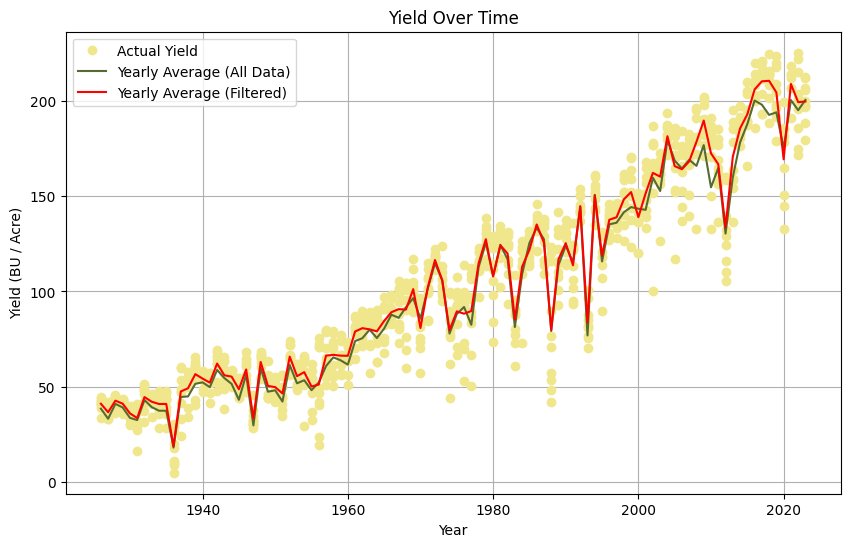

In [62]:
# Remove rows with missing yield values
data = data.dropna(subset=['yield'])
print(f"Final dataset length: {len(data)}")

# Visualize updated yield trends
average_yield_per_year2 = data.groupby('Year')['yield'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(data['Year'], data['yield'], marker='o', linestyle='', color='khaki', label='Actual Yield')
plt.plot(average_yield_per_year.index, average_yield_per_year, color='darkolivegreen', label='Yearly Average (All Data)')
plt.plot(average_yield_per_year2['Year'], average_yield_per_year2['yield'], color='red', label='Yearly Average (Filtered)')
plt.xlabel('Year')
plt.ylabel('Yield (BU / Acre)')
plt.title('Yield Over Time')
plt.grid()
plt.legend()
plt.show()


This graph shows the changes in crop yield (measured in bushels per acre) over time, from the early 1900s to the 2020s. The yellow dots represent the actual yield for each year, showing a significant amount of variability. The green line represents the yearly average across all the data, while the red line shows a filtered yearly average, likely smoothing out extreme values to highlight trends more clearly. There is a noticeable upward trend in yields over time, particularly after the 1950s, which could be attributed to advancements in farming practices, technology, or crop quality. Despite this upward trend, there are periods where yields dropped significantly, such as in the early 1930s, late 1980s, and around 2005. These dips might reflect external challenges like poor weather, pests, or economic conditions. 

# 3. Baseline Model
## 3.1 Linear Regression Model

Model Training and Testing

The features (X) and target variable (y) are prepared by dropping irrelevant columns from the dataset. The data is split into training and testing sets with an 80-20 ratio, ensuring a representative sample for evaluation. A linear regression model is initialized and trained on the training set, providing a straightforward baseline for crop yield prediction.

Model Evaluation

The trained model is used to predict crop yields for the test set. Key metrics, including Mean Squared Error (MSE) and R-squared (R²), are calculated to assess model performance. The coefficients of the model are displayed to provide insight into feature importance.

A scatter plot visualizes the relationship between actual and predicted values, with an ideal fit line for reference. This plot highlights the baseline model's predictive accuracy and serves as a benchmark for comparison with more complex models.

Calculating the correlation matrix for key features...


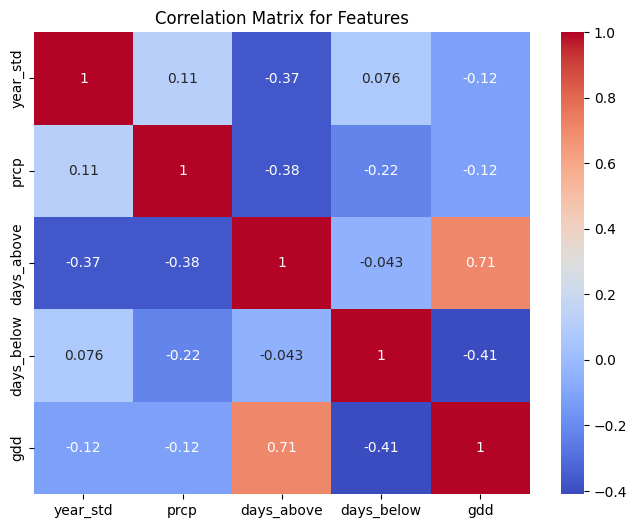

In [63]:
# Calculate and display the correlation matrix
print("Calculating the correlation matrix for key features...")
correlation_matrix = data[['year_std', 'prcp', 'days_above', 'days_below', 'gdd']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Features')
plt.show()

This correlation matrix shows how the features are related to each other, with values from -1 to 1. Positive values mean the features increase together, while negative ones mean one goes up and the other goes down. For example, “days_above” and “gdd” have a strong positive correlation of 0.71, showing that as hot days increase, growing degree days also rise. On the other hand, “days_below” and “gdd” are negatively correlated at -0.41, meaning colder days reduce growing degree days.

The relationships with “year_std” are weaker, with the highest being 0.11 for “prcp”. This suggests that over time, these variables didn’t change much together. This matrix helps to spot the strongest connections, like “days_above” and “gdd,” and weaker ones, like “year_std” and “days_below.”

### Model Training and Testing

In [64]:
# Prepare features and target variable
print("Preparing the features and target variable...")
X = data.drop(['id', 'yield', 'name', 'Year', 'County'], axis=1)
y = data['yield']

# Split data into training and testing sets
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}, Testing set size: {len(X_test)}")

# Initialize and fit the model
print("Fitting the Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training completed.")



Preparing the features and target variable...
Splitting data into training and testing sets...
Training set size: 780, Testing set size: 196
Fitting the Linear Regression model...
Model training completed.


### Model Evaluation

Making predictions on the test set...

Model Evaluation Metrics:
Mean Squared Error (MSE): 202.42
R-squared (R²): 0.92

Model Coefficients:
                   Coefficient
year^2             1414.018915
year_std          -1366.318799
gdd x prcp           32.921066
prcp                -32.389986
days_above           -8.439260
days_below           -1.977983
gdd                 -10.053123
County_CARROLL       -0.465732
County_CHEROKEE       1.952407
County_CLINTON       -2.116859
County_LINN          -3.985742
County_O BRIEN       -0.984911
County_PAGE         -14.483467
County_PLYMOUTH      -5.894665
County_TAMA          -0.732256
County_WASHINGTON    -4.390088


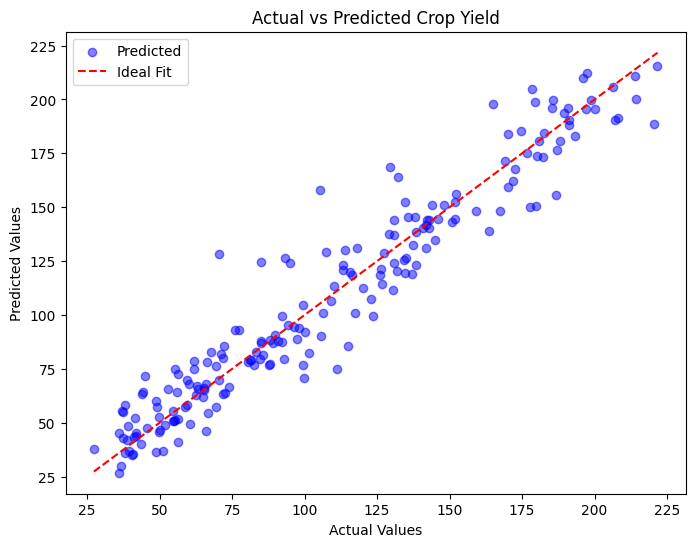

In [65]:
# Make predictions
print("Making predictions on the test set...")
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Display coefficients
print("\nModel Coefficients:")
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

# Visualization of Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')  # Identity line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Crop Yield')
plt.legend()
plt.show()


This scatter plot shows the relationship between the actual crop yield and the predicted crop yield. Each blue dot represents a data point, with the x-axis showing the actual values and the y-axis showing the predicted values. The red dashed line represents the ideal fit, which is where the predictions would perfectly match the actual values.

Most of the points are close to the red line, showing that the model does a good job predicting crop yield overall. Some points are scattered further away, especially for higher values, which shows there might be some errors or inconsistencies in the predictions. The trend is clear though - as the actual values increase, the predicted values also increase, showing a strong positive relationship between the two. This graph shows that the model is fairly accurate but not perfect, especially at extreme values

## 3.2 LASSO model
### Data Scaling, Model Training, and Hyperparameter Tuning


#### Data Scaling, Model Training, and Hyperparameter Tuning
The features are standardized using `StandardScaler` to ensure all variables have the same scale, which is crucial for the LASSO regression. A `LassoCV` model with 5-fold cross-validation is trained on the scaled training data. The optimal regularization parameter (`alpha`) is automatically selected during training, balancing model complexity and performance.

#### Model Evaluation and Analysis
Predictions are made on the scaled test data, and the model's performance is evaluated using Mean Squared Error (MSE) and R-squared (R²). These metrics provide insight into the model's accuracy and explanatory power.

The importance of each feature is analyzed by visualizing the LASSO coefficients, which highlight features retained by the model after regularization. A detailed table of coefficients is also provided for further interpretation.

Finally, the relationship between actual and predicted values is visualized using a scatter plot with an ideal fit line, illustrating the model's predictive capability and potential areas for improvement.

In [66]:
# Scale the training and testing data
print("Scaling the training and testing data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaling completed.")

# Train Lasso with cross-validation
print("Training Lasso Regression with cross-validation...")
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)
print(f"Lasso training completed. Best alpha found: {lasso.alpha_:.4f}")



Scaling the training and testing data...
Data scaling completed.
Training Lasso Regression with cross-validation...
Lasso training completed. Best alpha found: 0.0505


### Model Evaluation and Analysis

Making predictions on the test set...

Model Evaluation Metrics:
Mean Squared Error (MSE): 267.31
R-squared (R²): 0.90

Visualizing feature importance using Lasso coefficients...


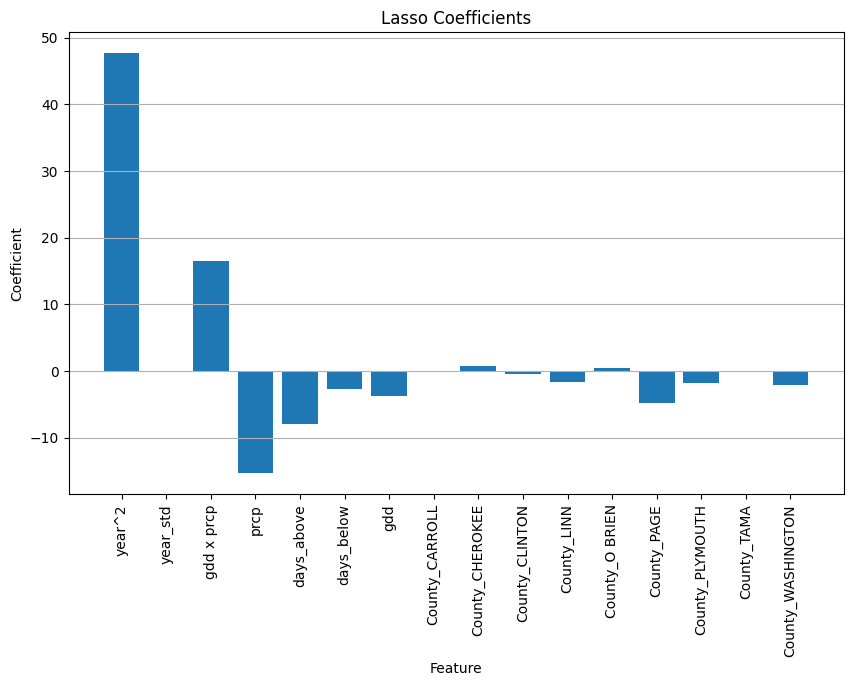


Lasso Coefficients:
              Feature  Coefficient
0              year^2    47.656045
2          gdd x prcp    16.524482
8     County_CHEROKEE     0.764886
11     County_O BRIEN     0.428349
1            year_std    -0.000000
7      County_CARROLL    -0.000000
14        County_TAMA    -0.175823
9      County_CLINTON    -0.510373
10        County_LINN    -1.590013
13    County_PLYMOUTH    -1.750907
15  County_WASHINGTON    -2.130968
5          days_below    -2.721284
6                 gdd    -3.740328
12        County_PAGE    -4.745033
4          days_above    -7.892143
3                prcp   -15.339979

Visualizing the relationship between actual and predicted values...


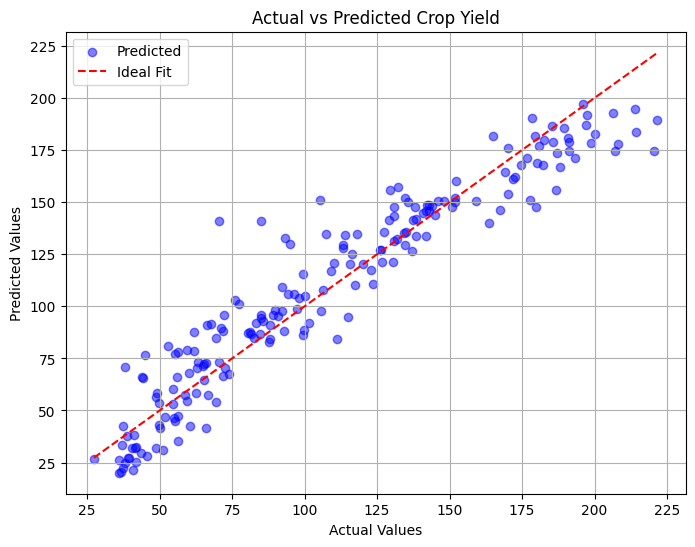

In [67]:
# Make predictions
print("Making predictions on the test set...")
y_pred = lasso.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Visualize Lasso coefficients
print("\nVisualizing feature importance using Lasso coefficients...")
plt.figure(figsize=(10, 6))
plt.bar(X.columns, lasso.coef_)
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Lasso Coefficients')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()

# Create a DataFrame of feature coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})
print("\nLasso Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

# Plot actual vs predicted values
print("\nVisualizing the relationship between actual and predicted values...")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')  # Identity line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Crop Yield')
plt.legend()
plt.grid()
plt.show()


Graph 1: Lasso Coefficients

This bar chart shows the Lasso regression coefficients for different features, which represent their importance in predicting crop yield. The feature “year^2” has the largest positive coefficient, meaning it strongly contributes to increasing the predicted yield. The second most important is “gdd x prcp,” while “prcp” has the most negative impact with a large negative coefficient. Other features like “days_above,” “days_below,” and some counties have smaller coefficients, either positive or negative. The fact that some coefficients are close to zero means these features contribute very little to the prediction, likely because Lasso regression shrinks less important features.

Graph 2: Actual vs Predicted Crop Yield

This scatter plot shows the actual crop yields on the x-axis and the predicted yields on the y-axis. Each blue dot represents a prediction, and the red dashed line shows the ideal fit where predicted values perfectly match the actual ones. Most of the points are clustered near the red line, showing the model predicts the crop yield fairly well. However, some dots are scattered further away, especially for higher yields, indicating prediction errors. The positive trend shows the model captures the general pattern, where higher actual yields tend to result in higher predictions.

# 4. Final Model Pipeline

## 4.1 Decision Tree Model


#### 4.1 Decision Tree Model

The Decision Tree model is trained using `GridSearchCV` to optimize hyperparameters, including tree depth, minimum samples per split, and minimum samples per leaf. The best model is evaluated on the test set, with Mean Squared Error (MSE) and R-squared (R²) as performance metrics. The decision tree structure is visualized to provide insight into the splits and decision paths. A scatter plot of actual vs. predicted values assesses the model's accuracy.

#### 4.2 Random Forest Model

Using the same hyperparameter grid as the Decision Tree, the Random Forest model is optimized with `GridSearchCV`. The best-performing model is evaluated on the test set, reporting MSE and R². Feature importances are analyzed and visualized, ranking variables by their contribution to the model. A scatter plot of actual vs. predicted values and a time series plot of predictions vs. actual values across years highlights the model's performance and consistency over time.

#### Partial Dependence

A partial dependence plot is generated for the `days_above` feature (days above 90°F) to illustrate its marginal effect on crop yield. This provides interpretability, showing how changes in extreme temperature days influence the yield, independent of othe

### Training, Hyperparameter Tuning, and Evaluationr variables.

In [68]:
# Define the hyperparameter grid
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [6, 7, 8, 9],
    'min_samples_leaf': [2, 3, 4, 5],
    'max_features': ['sqrt', None]
}

# Initialize DecisionTreeRegressor and GridSearchCV
print("Training the Decision Tree model with GridSearchCV...")
dt_regressor = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=dt_regressor, param_grid=param_grid,
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Evaluate the best model
best_dt_regressor = grid_search.best_estimator_
y_pred = best_dt_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nBest Decision Tree Hyperparameters: {grid_search.best_params_}")
print(f"Decision Tree Mean Squared Error (MSE): {mse:.2f}")
print(f"Decision Tree R-squared (R²): {r2:.2f}")


Training the Decision Tree model with GridSearchCV...

Best Decision Tree Hyperparameters: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 6}
Decision Tree Mean Squared Error (MSE): 190.46
Decision Tree R-squared (R²): 0.93


### Visualization: Decision Tree and Predictions

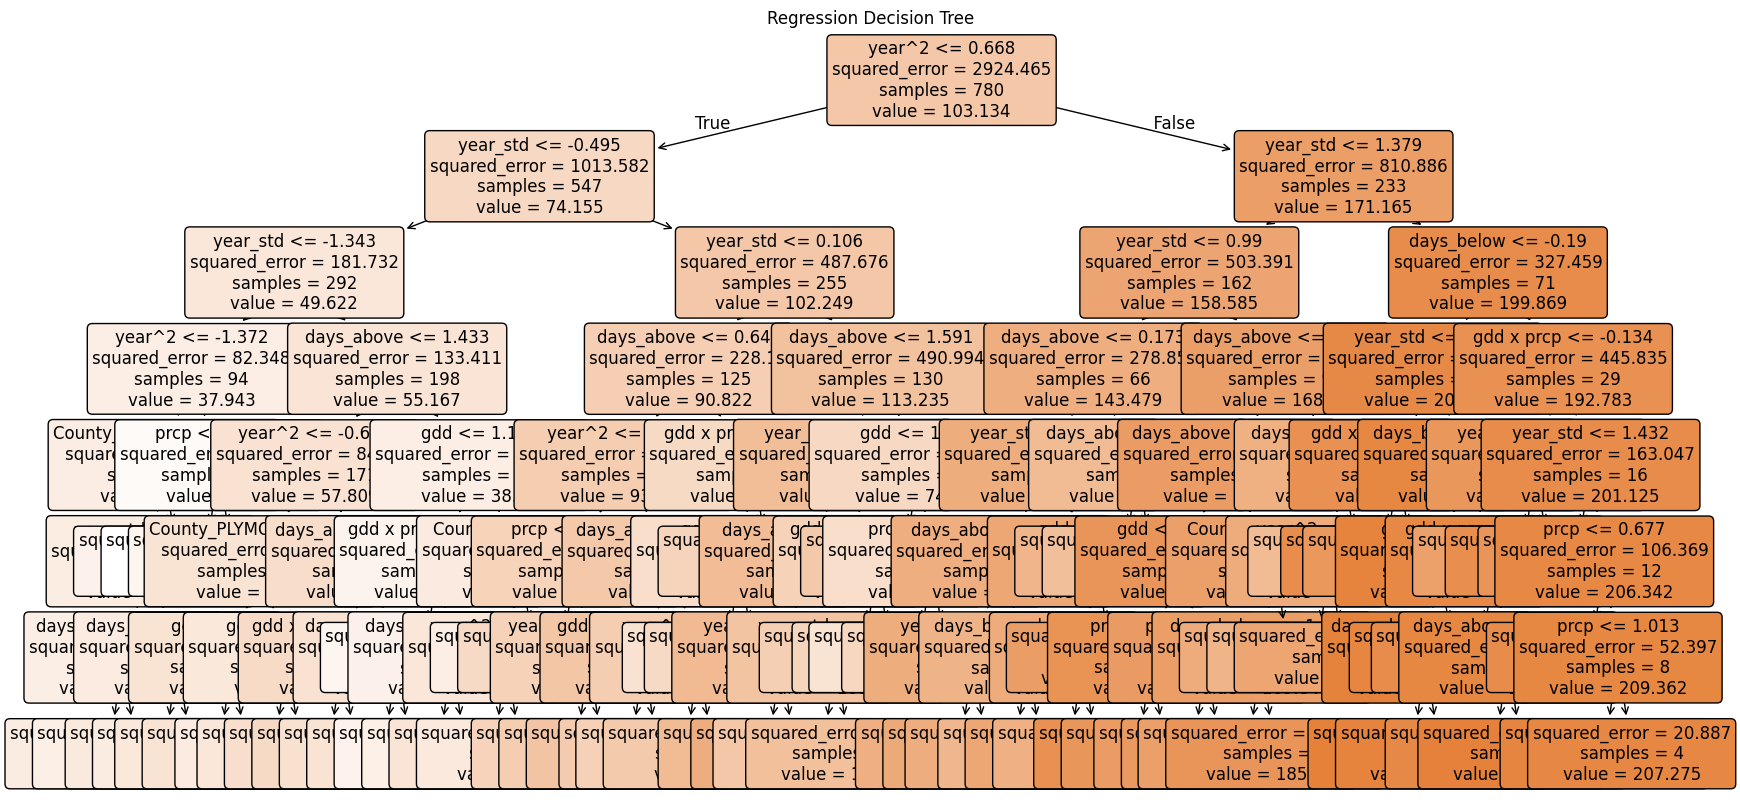

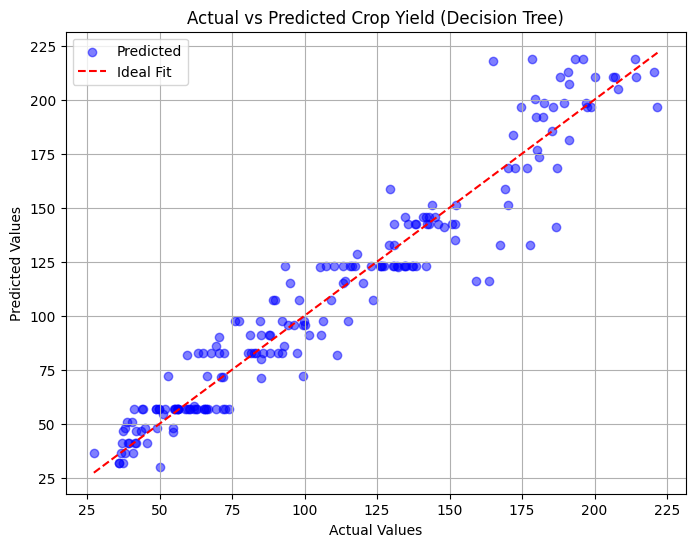

In [69]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(best_dt_regressor, filled=True, feature_names=X.columns, rounded=True, fontsize=12)
plt.title('Regression Decision Tree')
plt.show()

# Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Crop Yield (Decision Tree)')
plt.legend()
plt.grid()
plt.show()


## 4.2 Random Forest Model
### Training, Hyperparameter Tuning, and Evaluation

In [70]:
# Define hyperparameter grid (same as Decision Tree for simplicity)
print("Training the Random Forest model with GridSearchCV...")
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid,
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2
)
grid_search.fit(X_train, y_train)

# Evaluate the best model
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nBest Random Forest Hyperparameters: {grid_search.best_params_}")
print(f"Random Forest Mean Squared Error (MSE): {mse:.2f}")
print(f"Random Forest R-squared (R²): {r2:.2f}")

Training the Random Forest model with GridSearchCV...
Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=6; total time=   0.1s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=6; total time=   0.1s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=6; total time=   0.1s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=6; total time=   0.1s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=6; total time=   0.1s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=7; total time=   0.1s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=7; total time=   0.2s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_split=7; total time=   0.2s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=2, min_samples_sp

### Feature Importance


Feature Importances (Random Forest):
year_std: 0.5124
year^2: 0.4319
days_above: 0.0355
gdd: 0.0063
prcp: 0.0039
gdd x prcp: 0.0033
County_PAGE: 0.0026
days_below: 0.0021
County_PLYMOUTH: 0.0008
County_WASHINGTON: 0.0004
County_TAMA: 0.0002
County_O BRIEN: 0.0002
County_CHEROKEE: 0.0001
County_CLINTON: 0.0001
County_CARROLL: 0.0001
County_LINN: 0.0001


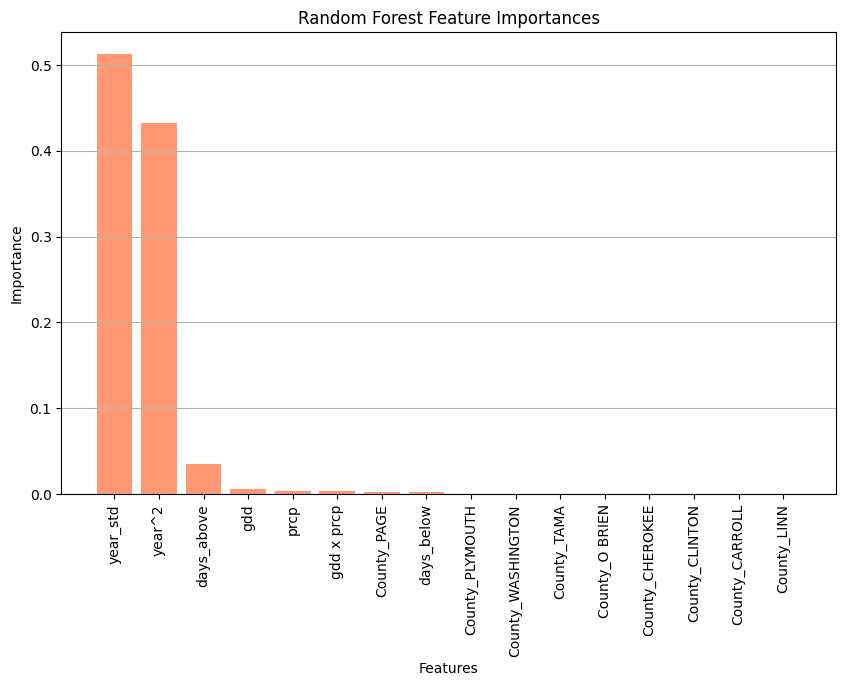

In [71]:
# Display feature importances
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature Importances (Random Forest):")
for i, idx in enumerate(indices):
    print(f"{X.columns[idx]}: {importances[idx]:.4f}")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(X.columns[indices], importances[indices], color='coral', alpha=0.8)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importances')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()


### Visualizing Predictions

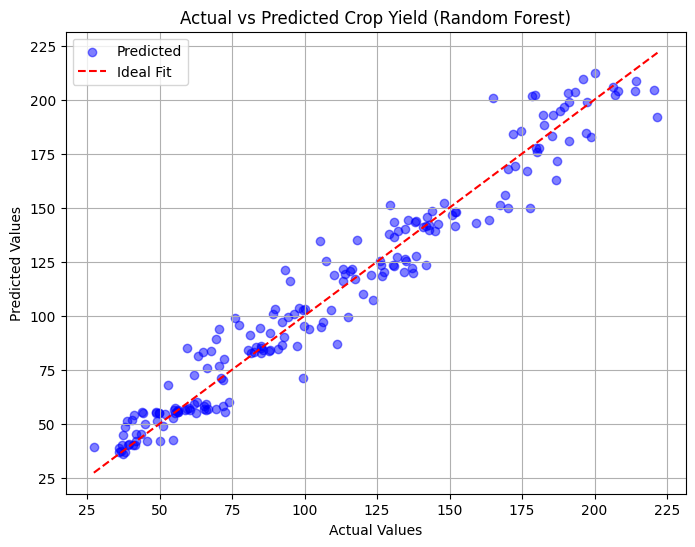

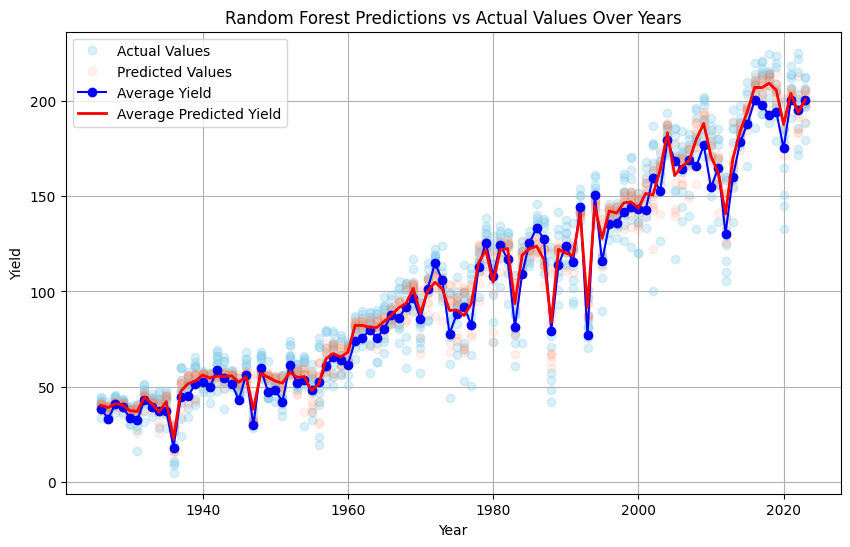

In [72]:
# Scatter plot of Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Crop Yield (Random Forest)')
plt.legend()
plt.grid()
plt.show()

# Add predicted values to the dataset
predicted_values = best_rf.predict(X)
predicted_df = data.copy()
predicted_df['Predicted Yield'] = predicted_values

# Average predicted yield per year
average_predicted_yield_per_year = predicted_df.groupby('Year')['Predicted Yield'].mean()

# Plot actual vs predicted yield over years
plt.figure(figsize=(10, 6))
plt.plot(data['Year'], data['yield'], label='Actual Values', color='skyblue', marker='o', linestyle='', alpha=0.3)
plt.plot(data['Year'], best_rf.predict(X), label='Predicted Values', color='coral', marker='o', linestyle='', alpha=0.1)
plt.plot(average_yield_per_year.index, average_yield_per_year, label='Average Yield', color='blue', linestyle='-', marker='o')
plt.plot(average_predicted_yield_per_year.index, average_predicted_yield_per_year, label='Average Predicted Yield', color='red', linestyle='-', linewidth=2)
plt.title('Random Forest Predictions vs Actual Values Over Years')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.grid()
plt.show()



### Partial Dependence

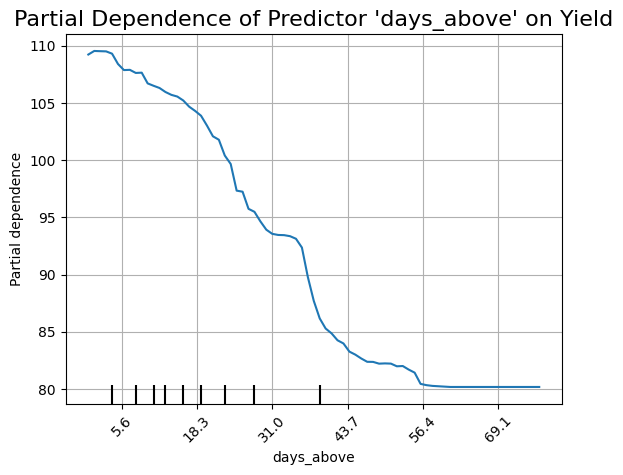

In [73]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

temperature_features = ['days_above']

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    temperature_features,
    grid_resolution=100,  # Number of samples simulated per feature
)
plt.title("Partial Dependence of Predictor 'days_above' on Yield", fontsize=16)

# Unscale days_above values
x_ticks = np.array([-1, 0, 1, 2, 3, 4])
x_labels = x_ticks * climate_summary['days_above'].std() + climate_summary['days_above'].mean()
x_labels = np.round(x_labels, decimals=1)
plt.xticks(x_ticks, x_labels, rotation=45)

plt.grid()
plt.show()